In [1]:
# CELL 1: Imports
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import pytz
from datetime import timedelta, time
import matplotlib.pyplot as plt
print("All libraries imported successfully")


All libraries imported successfully


In [2]:
# CELL 2: Load Kaggle CSV Data

def load_csv(filename):
    """Load a Kaggle tab-separated file and prepare it."""
    df = pd.read_csv(filename, sep='\t')
    
    # Parse DateTime (format includes seconds)
    df['DateTime'] = pd.to_datetime(df['DateTime'], format='%Y.%m.%d %H:%M:%S')
    
    # Set as index, sort ascending
    df = df.set_index('DateTime').sort_index()
    
    # Localize to NY time
    df.index = df.index.tz_localize('America/New_York', ambiguous='infer', nonexistent='shift_forward')
    
    # Keep only OHLC
    df = df[['Open', 'High', 'Low', 'Close']]
    df.columns = ['open', 'high', 'low', 'close']
    
    return df

# Load all timeframes
nas_1m  = load_csv('1m_data.csv')
nas_5m  = load_csv('5m_data.csv')
nas_15m = load_csv('15m_data.csv')
nas_1h  = load_csv('1h_data.csv')
nas_1d  = load_csv('1d_data.csv')

print("Loaded all NAS100 timeframes:")
print(f"  1m : {len(nas_1m):>8,} rows | {nas_1m.index[0]} → {nas_1m.index[-1]}")
print(f"  5m : {len(nas_5m):>8,} rows | {nas_5m.index[0]} → {nas_5m.index[-1]}")
print(f"  15m: {len(nas_15m):>8,} rows | {nas_15m.index[0]} → {nas_15m.index[-1]}")
print(f"  1h : {len(nas_1h):>8,} rows | {nas_1h.index[0]} → {nas_1h.index[-1]}")
print(f"  1d : {len(nas_1d):>8,} rows | {nas_1d.index[0]} → {nas_1d.index[-1]}")

print("\nSample of 1-minute data:")
print(nas_1m.head())

Loaded all NAS100 timeframes:
  1m : 3,077,548 rows | 2016-11-15 06:33:00-05:00 → 2025-10-01 07:12:00-04:00
  5m :  618,968 rows | 2016-11-15 06:30:00-05:00 → 2025-10-01 07:10:00-04:00
  15m:  206,703 rows | 2016-11-15 06:30:00-05:00 → 2025-10-01 07:00:00-04:00
  1h :   51,889 rows | 2016-11-15 06:00:00-05:00 → 2025-10-01 07:00:00-04:00
  1d :    2,283 rows | 2016-11-15 00:00:00-05:00 → 2025-10-01 00:00:00-04:00

Sample of 1-minute data:
                             open    high     low   close
DateTime                                                 
2016-11-15 06:33:00-05:00  4699.6  4699.9  4699.6  4699.9
2016-11-15 06:34:00-05:00  4699.9  4700.2  4699.7  4700.2
2016-11-15 06:35:00-05:00  4700.4  4700.4  4699.9  4700.3
2016-11-15 06:36:00-05:00  4700.4  4700.7  4700.2  4700.7
2016-11-15 06:37:00-05:00  4700.8  4701.0  4700.5  4700.5


In [3]:
# CELL 3: Trim to Backtest Window (2020-2025)

START = '2020-01-01'
END   = '2025-01-01'

def trim(df, start, end):
    """Keep only rows within the backtest window."""
    return df.loc[start:end]

nas_1m  = trim(nas_1m,  START, END)
nas_5m  = trim(nas_5m,  START, END)
nas_15m = trim(nas_15m, START, END)
nas_1h  = trim(nas_1h,  START, END)
nas_1d  = trim(nas_1d,  START, END)

print(f"Trimmed to {START} → {END}:")
print(f"  1m : {len(nas_1m):>8,} rows | {nas_1m.index[0]} → {nas_1m.index[-1]}")
print(f"  5m : {len(nas_5m):>8,} rows")
print(f"  15m: {len(nas_15m):>8,} rows")
print(f"  1h : {len(nas_1h):>8,} rows")
print(f"  1d : {len(nas_1d):>8,} rows | {nas_1d.index[0]} → {nas_1d.index[-1]}")

Trimmed to 2020-01-01 → 2025-01-01:
  1m : 1,754,320 rows | 2020-01-02 01:00:00-05:00 → 2024-12-31 23:59:00-05:00
  5m :  351,042 rows
  15m:  117,100 rows
  1h :   29,326 rows
  1d :    1,286 rows | 2020-01-02 00:00:00-05:00 → 2024-12-31 00:00:00-05:00


In [4]:
# CELL 4: Strategy Parameters

OR_START = '09:30'
OR_END = '09:45'
MARKET_OPEN = '09:30'
MARKET_CLOSE = '16:00'

RR_CONFIGS = {
    'RR_1_1': {'type': 'fixed', 'ratio': 1.0},
    'RR_2_1': {'type': 'fixed', 'ratio': 2.0},
    'RR_3_1': {'type': 'fixed', 'ratio': 3.0},
}

EXIT_AT_CLOSE = True
SLIPPAGE = 0.0
COMMISSION_PER_TRADE = 0.0
MAX_TRADES_PER_DAY = 1

print(f"{'='*60}")
print("STRATEGY PARAMETERS")
print(f"{'='*60}")
print(f"Opening Range:          {OR_START} - {OR_END} ET")
print(f"Market Hours:           {MARKET_OPEN} - {MARKET_CLOSE} ET")
print(f"RR Configs:             {', '.join(RR_CONFIGS.keys())}")
print(f"Exit at market close:   {EXIT_AT_CLOSE}")
print(f"Slippage:               {SLIPPAGE} points")
print(f"Commission per trade:   {COMMISSION_PER_TRADE} points")
print(f"Max trades per day:     {MAX_TRADES_PER_DAY}")

STRATEGY PARAMETERS
Opening Range:          09:30 - 09:45 ET
Market Hours:           09:30 - 16:00 ET
RR Configs:             RR_1_1, RR_2_1, RR_3_1
Exit at market close:   True
Slippage:               0.0 points
Commission per trade:   0.0 points
Max trades per day:     1


In [5]:
# CELL 5: Setup 1 - Immediate 5-Minute Breakout
# RISK 1% OF ENTRY PRICE PER TRADE

def run_setup1_with_rr(df_5m, rr_config_name, risk_pct=0.01):
    """
    Setup 1: Immediate 5-min breakout, SL at low of entry candle.
    Tests different RR configurations.
    RISK: 1% of entry price per trade.
    
    rr_config_name: 'RR_1_1', 'RR_2_1', 'RR_3_1'
    risk_pct: percentage of entry price to risk (default 0.01 = 1%)
    """
    
    rr_config = RR_CONFIGS[rr_config_name]
    trades = []
    df_5m['date'] = df_5m.index.date
    
    for date, day_data in df_5m.groupby('date'):
        # Extract the opening range
        or_window = day_data.between_time(OR_START, OR_END)
        
        if len(or_window) == 0:
            continue
        
        or_high = or_window['high'].max()
        or_low = or_window['low'].min()
        or_mid = (or_high + or_low) / 2
        
        # Data after OR closes
        post_or = day_data[day_data.index.time > pd.to_datetime(OR_END).time()]
        
        if len(post_or) == 0:
            continue
        
        # Find first breakout
        entry_signal = None
        entry_idx = None
        
        for idx, (ts, candle) in enumerate(post_or.iterrows()):
            if ts.time() >= pd.to_datetime(MARKET_CLOSE).time():
                break
            
            # Long breakout
            if candle['close'] > or_high and entry_signal is None:
                entry_signal = 'long'
                entry_idx = idx
                entry_time = ts
                entry_price = candle['close']
                entry_candle_low = candle['low']
                break
            
            # Short breakout
            elif candle['close'] < or_low and entry_signal is None:
                entry_signal = 'short'
                entry_idx = idx
                entry_time = ts
                entry_price = candle['close']
                entry_candle_high = candle['high']
                break
        
        if entry_signal is None:
            continue
        
        # Calculate fixed risk in points (1% of entry price)
        fixed_risk = entry_price * risk_pct
        
        # Calculate actual risk from SL
        if entry_signal == 'long':
            sl_price = entry_candle_low
            actual_risk_per_unit = entry_price - sl_price
        else:  # short
            sl_price = entry_candle_high
            actual_risk_per_unit = sl_price - entry_price
        
        # Skip if risk is zero or negative
        if actual_risk_per_unit <= 0:
            continue
        
        # Calculate position size to achieve fixed_risk
        position_size = fixed_risk / actual_risk_per_unit
        
        # Set up TP based on RR type
        ratio = rr_config['ratio']
        if entry_signal == 'long':
            tp_price = entry_price + (actual_risk_per_unit * ratio)
        else:
            tp_price = entry_price - (actual_risk_per_unit * ratio)
        
        # Track exit
        remaining_candles = post_or.iloc[entry_idx+1:]
        exit_time = None
        exit_price = None
        exit_reason = None
        
        for ts, candle in remaining_candles.iterrows():
            if ts.time() >= pd.to_datetime(MARKET_CLOSE).time():
                if EXIT_AT_CLOSE:
                    exit_time = ts
                    exit_price = candle['close']
                    exit_reason = 'market_close'
                break
            
            if entry_signal == 'long':
                if candle['high'] >= tp_price:
                    exit_time = ts
                    exit_price = tp_price
                    exit_reason = 'tp_hit'
                    break
                elif candle['low'] <= sl_price:
                    exit_time = ts
                    exit_price = sl_price
                    exit_reason = 'sl_hit'
                    break
            else:  # short
                if candle['low'] <= tp_price:
                    exit_time = ts
                    exit_price = tp_price
                    exit_reason = 'tp_hit'
                    break
                elif candle['high'] >= sl_price:
                    exit_time = ts
                    exit_price = sl_price
                    exit_reason = 'sl_hit'
                    break
        
        if exit_time is None:
            exit_time = remaining_candles.index[-1]
            exit_price = remaining_candles.iloc[-1]['close']
            exit_reason = 'end_of_data'
        
        # Calculate P&L in absolute terms (with position sizing)
        if entry_signal == 'long':
            pnl = (exit_price - entry_price) * position_size
        else:
            pnl = (entry_price - exit_price) * position_size
        
        trades.append({
            'date': date,
            'direction': entry_signal,
            'entry_time': entry_time,
            'entry_price': entry_price,
            'exit_time': exit_time,
            'exit_price': exit_price,
            'exit_reason': exit_reason,
            'or_high': or_high,
            'or_low': or_low,
            'or_mid': or_mid,
            'sl_price': sl_price,
            'tp_price': tp_price,
            'actual_risk_per_unit': actual_risk_per_unit,
            'fixed_risk': fixed_risk,
            'position_size': position_size,
            'pnl': pnl,
            'win': 1 if pnl > 0 else 0,
        })
    
    return pd.DataFrame(trades)


# ─── RUN SETUP 1 WITH ALL RR CONFIGS ───

results_s1 = {}

for rr_name in RR_CONFIGS.keys():
    trades = run_setup1_with_rr(nas_5m, rr_name, risk_pct=0.01)
    results_s1[rr_name] = trades
    
    # Calculate metrics
    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
    win_rate = trades['win'].mean() * 100
    
    print(f"\n{'='*60}")
    print(f"SETUP 1 - {rr_name}")
    print(f"{'='*60}")
    print(f"Total trades:           {len(trades):>6}")
    print(f"Winning trades:         {trades['win'].sum():>6}")
    print(f"Win rate:               {win_rate:>6.2f}%")
    print(f"\nTotal Return (P&L):     {total_return:>10.2f} points")
    print(f"Avg P&L per trade:      {trades['pnl'].mean():>10.4f} points")
    print(f"Max Drawdown:           {max_dd:>10.2f} points")
    print(f"Return / Max DD ratio:  {return_dd_ratio:>10.2f}x")
    print(f"\nAvg win:                {trades[trades['win']==1]['pnl'].mean() if len(trades[trades['win']==1]) > 0 else 0:>10.4f}")
    print(f"Avg loss:               {trades[trades['win']==0]['pnl'].mean() if len(trades[trades['win']==0]) > 0 else 0:>10.4f}")

print(f"\n{'='*60}")
print("SETUP 1 SUMMARY - ALL RR CONFIGS (RISK = 1% OF ENTRY)")
print(f"{'='*60}")

# Summary table
summary_data = []
for rr_name, trades in results_s1.items():
    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
    
    summary_data.append({
        'RR Config': rr_name,
        'Total Return': total_return,
        'Max DD': max_dd,
        'Return/DD': return_dd_ratio,
        'Win Rate %': trades['win'].mean() * 100,
        'Num Trades': len(trades)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ─── CALCULATE RETURN AS PERCENTAGE OF INITIAL CAPITAL ───

print(f"\n{'='*60}")
print("SETUP 1 - PERCENTAGE RETURN ON CAPITAL")
print(f"{'='*60}")
print("If you started with £10,000 capital:\n")

initial_capital = 10000

for rr_name, trades in results_s1.items():
    total_return = trades['pnl'].sum()
    return_pct = (total_return / initial_capital) * 100
    
    print(f"{rr_name:>12}: £{initial_capital:>7,.0f} → £{initial_capital + total_return:>7,.0f} | Return: {return_pct:>7.2f}%")


SETUP 1 - RR_1_1
Total trades:             1281
Winning trades:            634
Win rate:                49.49%

Total Return (P&L):       -1645.08 points
Avg P&L per trade:         -1.2842 points
Max Drawdown:             -7759.20 points
Return / Max DD ratio:        0.21x

Avg win:                  142.2437
Avg loss:                -141.9283

SETUP 1 - RR_2_1
Total trades:             1281
Winning trades:            429
Win rate:                33.49%

Total Return (P&L):         283.03 points
Avg P&L per trade:          0.2209 points
Max Drawdown:             -6994.83 points
Return / Max DD ratio:        0.04x

Avg win:                  281.5825
Avg loss:                -141.4505

SETUP 1 - RR_3_1
Total trades:             1281
Winning trades:            336
Win rate:                26.23%

Total Return (P&L):        2286.72 points
Avg P&L per trade:          1.7851 points
Max Drawdown:             -6648.70 points
Return / Max DD ratio:        0.34x

Avg win:                  405.15

In [6]:
# CELL 6: Setup 2 - 5-Minute Breakout, Midpoint SL
# RISK 1% OF ENTRY PRICE PER TRADE

def run_setup2_with_rr(df_5m, rr_config_name, risk_pct=0.01):
    """
    Setup 2: 5-min breakout, SL at OR midpoint.
    Tests different RR configurations.
    RISK: 1% of entry price per trade.
    
    rr_config_name: 'RR_1_1', 'RR_2_1', 'RR_3_1'
    risk_pct: percentage of entry price to risk (default 0.01 = 1%)
    """
    
    rr_config = RR_CONFIGS[rr_config_name]
    trades = []
    df_5m['date'] = df_5m.index.date
    
    for date, day_data in df_5m.groupby('date'):
        # Extract the opening range
        or_window = day_data.between_time(OR_START, OR_END)
        
        if len(or_window) == 0:
            continue
        
        or_high = or_window['high'].max()
        or_low = or_window['low'].min()
        or_mid = (or_high + or_low) / 2
        
        # Data after OR closes
        post_or = day_data[day_data.index.time > pd.to_datetime(OR_END).time()]
        
        if len(post_or) == 0:
            continue
        
        # Find first breakout
        entry_signal = None
        entry_idx = None
        
        for idx, (ts, candle) in enumerate(post_or.iterrows()):
            if ts.time() >= pd.to_datetime(MARKET_CLOSE).time():
                break
            
            # Long breakout
            if candle['close'] > or_high and entry_signal is None:
                entry_signal = 'long'
                entry_idx = idx
                entry_time = ts
                entry_price = candle['close']
                break
            
            # Short breakout
            elif candle['close'] < or_low and entry_signal is None:
                entry_signal = 'short'
                entry_idx = idx
                entry_time = ts
                entry_price = candle['close']
                break
        
        if entry_signal is None:
            continue
        
        # Calculate fixed risk in points (1% of entry price)
        fixed_risk = entry_price * risk_pct
        
        # Calculate actual risk from SL
        # SL is always OR midpoint for Setup 2
        sl_price = or_mid
        
        if entry_signal == 'long':
            actual_risk_per_unit = entry_price - sl_price
        else:  # short
            actual_risk_per_unit = sl_price - entry_price
        
        # If risk is negative or zero, skip
        if actual_risk_per_unit <= 0:
            continue
        
        # Calculate position size to achieve fixed_risk
        position_size = fixed_risk / actual_risk_per_unit
        
        # Set up TP based on RR type
        ratio = rr_config['ratio']
        if entry_signal == 'long':
            tp_price = entry_price + (actual_risk_per_unit * ratio)
        else:
            tp_price = entry_price - (actual_risk_per_unit * ratio)
        
        # Track exit
        remaining_candles = post_or.iloc[entry_idx+1:]
        exit_time = None
        exit_price = None
        exit_reason = None
        
        for ts, candle in remaining_candles.iterrows():
            if ts.time() >= pd.to_datetime(MARKET_CLOSE).time():
                if EXIT_AT_CLOSE:
                    exit_time = ts
                    exit_price = candle['close']
                    exit_reason = 'market_close'
                break
            
            if entry_signal == 'long':
                if candle['high'] >= tp_price:
                    exit_time = ts
                    exit_price = tp_price
                    exit_reason = 'tp_hit'
                    break
                elif candle['low'] <= sl_price:
                    exit_time = ts
                    exit_price = sl_price
                    exit_reason = 'sl_hit'
                    break
            else:  # short
                if candle['low'] <= tp_price:
                    exit_time = ts
                    exit_price = tp_price
                    exit_reason = 'tp_hit'
                    break
                elif candle['high'] >= sl_price:
                    exit_time = ts
                    exit_price = sl_price
                    exit_reason = 'sl_hit'
                    break
        
        if exit_time is None:
            exit_time = remaining_candles.index[-1]
            exit_price = remaining_candles.iloc[-1]['close']
            exit_reason = 'end_of_data'
        
        # Calculate P&L in absolute terms (with position sizing)
        if entry_signal == 'long':
            pnl = (exit_price - entry_price) * position_size
        else:
            pnl = (entry_price - exit_price) * position_size
        
        trades.append({
            'date': date,
            'direction': entry_signal,
            'entry_time': entry_time,
            'entry_price': entry_price,
            'exit_time': exit_time,
            'exit_price': exit_price,
            'exit_reason': exit_reason,
            'or_high': or_high,
            'or_low': or_low,
            'or_mid': or_mid,
            'sl_price': sl_price,
            'tp_price': tp_price,
            'actual_risk_per_unit': actual_risk_per_unit,
            'fixed_risk': fixed_risk,
            'position_size': position_size,
            'pnl': pnl,
            'win': 1 if pnl > 0 else 0,
        })
    
    return pd.DataFrame(trades)


# ─── RUN SETUP 2 WITH ALL RR CONFIGS ───

results_s2 = {}

for rr_name in RR_CONFIGS.keys():
    trades = run_setup2_with_rr(nas_5m, rr_name, risk_pct=0.01)
    results_s2[rr_name] = trades
    
    # Calculate metrics
    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
    win_rate = trades['win'].mean() * 100
    
    print(f"\n{'='*60}")
    print(f"SETUP 2 - {rr_name}")
    print(f"{'='*60}")
    print(f"Total trades:           {len(trades):>6}")
    print(f"Winning trades:         {trades['win'].sum():>6}")
    print(f"Win rate:               {win_rate:>6.2f}%")
    print(f"\nTotal Return (P&L):     {total_return:>10.2f} points")
    print(f"Avg P&L per trade:      {trades['pnl'].mean():>10.4f} points")
    print(f"Max Drawdown:           {max_dd:>10.2f} points")
    print(f"Return / Max DD ratio:  {return_dd_ratio:>10.2f}x")
    print(f"\nAvg win:                {trades[trades['win']==1]['pnl'].mean() if len(trades[trades['win']==1]) > 0 else 0:>10.4f}")
    print(f"Avg loss:               {trades[trades['win']==0]['pnl'].mean() if len(trades[trades['win']==0]) > 0 else 0:>10.4f}")

print(f"\n{'='*60}")
print("SETUP 2 SUMMARY - ALL RR CONFIGS (RISK = 1% OF ENTRY)")
print(f"{'='*60}")

# Summary table
summary_data_s2 = []
for rr_name, trades in results_s2.items():
    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
    
    summary_data_s2.append({
        'RR Config': rr_name,
        'Total Return': total_return,
        'Max DD': max_dd,
        'Return/DD': return_dd_ratio,
        'Win Rate %': trades['win'].mean() * 100,
        'Num Trades': len(trades)
    })

summary_df_s2 = pd.DataFrame(summary_data_s2)
print(summary_df_s2.to_string(index=False))

# ─── CALCULATE RETURN AS PERCENTAGE OF INITIAL CAPITAL ───

print(f"\n{'='*60}")
print("SETUP 2 - PERCENTAGE RETURN ON CAPITAL")
print(f"{'='*60}")
print("If you started with £10,000 capital:\n")

initial_capital = 10000

for rr_name, trades in results_s2.items():
    total_return = trades['pnl'].sum()
    return_pct = (total_return / initial_capital) * 100
    
    print(f"{rr_name:>12}: £{initial_capital:>7,.0f} → £{initial_capital + total_return:>7,.0f} | Return: {return_pct:>7.2f}%")


SETUP 2 - RR_1_1
Total trades:             1281
Winning trades:            626
Win rate:                48.87%

Total Return (P&L):       -3935.77 points
Avg P&L per trade:         -3.0724 points
Max Drawdown:             -4697.96 points
Return / Max DD ratio:        0.84x

Avg win:                  141.9102
Avg loss:                -141.6359

SETUP 2 - RR_2_1
Total trades:             1281
Winning trades:            421
Win rate:                32.86%

Total Return (P&L):       -6666.10 points
Avg P&L per trade:         -5.2038 points
Max Drawdown:             -9561.80 points
Return / Max DD ratio:        0.70x

Avg win:                  274.3497
Avg loss:                -142.0550

SETUP 2 - RR_3_1
Total trades:             1281
Winning trades:            342
Win rate:                26.70%

Total Return (P&L):        -844.89 points
Avg P&L per trade:         -0.6596 points
Max Drawdown:             -9124.57 points
Return / Max DD ratio:        0.09x

Avg win:                  386.66

In [7]:
# CELL 7: Setup 3 - Limit Order at OR, SL at Midpoint
# RISK 1% OF ENTRY PRICE PER TRADE

def run_setup3_with_rr(df_5m, rr_config_name, risk_pct=0.01):
    """
    Setup 3: Limit order placed at OR high/low, SL at OR midpoint.
    Tests different RR configurations.
    RISK: 1% of entry price per trade.
    
    rr_config_name: 'RR_1_1', 'RR_2_1', 'RR_3_1'
    risk_pct: percentage of entry price to risk (default 0.01 = 1%)
    """
    
    rr_config = RR_CONFIGS[rr_config_name]
    trades = []
    df_5m['date'] = df_5m.index.date
    
    for date, day_data in df_5m.groupby('date'):
        # Extract the opening range
        or_window = day_data.between_time(OR_START, OR_END)
        
        if len(or_window) == 0:
            continue
        
        or_high = or_window['high'].max()
        or_low = or_window['low'].min()
        or_mid = (or_high + or_low) / 2
        
        # Data after OR closes
        post_or = day_data[day_data.index.time > pd.to_datetime(OR_END).time()]
        
        if len(post_or) == 0:
            continue
        
        # Initialize limit orders (not yet filled)
        long_limit_filled = False
        short_limit_filled = False
        entry_signal = None
        entry_idx = None
        entry_time = None
        entry_price = None
        
        # Scan through post-OR candles for limit order fills
        for idx, (ts, candle) in enumerate(post_or.iterrows()):
            if ts.time() >= pd.to_datetime(MARKET_CLOSE).time():
                break
            
            # Long limit order at OR_high
            if not long_limit_filled and candle['low'] <= or_high and candle['high'] >= or_high:
                long_limit_filled = True
                entry_signal = 'long'
                entry_idx = idx
                entry_time = ts
                entry_price = or_high
                break
            
            # Short limit order at OR_low
            if not short_limit_filled and candle['low'] <= or_low and candle['high'] >= or_low:
                short_limit_filled = True
                entry_signal = 'short'
                entry_idx = idx
                entry_time = ts
                entry_price = or_low
                break
        
        if entry_signal is None:
            continue
        
        # Calculate fixed risk in points (1% of entry price)
        fixed_risk = entry_price * risk_pct
        
        # SL is OR midpoint for Setup 3
        sl_price = or_mid
        
        if entry_signal == 'long':
            actual_risk_per_unit = entry_price - sl_price
        else:  # short
            actual_risk_per_unit = sl_price - entry_price
        
        # If risk is negative or zero, skip
        if actual_risk_per_unit <= 0:
            continue
        
        # Calculate position size to achieve fixed_risk
        position_size = fixed_risk / actual_risk_per_unit
        
        # Set up TP based on RR type
        ratio = rr_config['ratio']
        if entry_signal == 'long':
            tp_price = entry_price + (actual_risk_per_unit * ratio)
        else:
            tp_price = entry_price - (actual_risk_per_unit * ratio)
        
        # Track exit
        remaining_candles = post_or.iloc[entry_idx+1:]
        exit_time = None
        exit_price = None
        exit_reason = None
        
        for ts, candle in remaining_candles.iterrows():
            if ts.time() >= pd.to_datetime(MARKET_CLOSE).time():
                if EXIT_AT_CLOSE:
                    exit_time = ts
                    exit_price = candle['close']
                    exit_reason = 'market_close'
                break
            
            if entry_signal == 'long':
                if candle['high'] >= tp_price:
                    exit_time = ts
                    exit_price = tp_price
                    exit_reason = 'tp_hit'
                    break
                elif candle['low'] <= sl_price:
                    exit_time = ts
                    exit_price = sl_price
                    exit_reason = 'sl_hit'
                    break
            else:  # short
                if candle['low'] <= tp_price:
                    exit_time = ts
                    exit_price = tp_price
                    exit_reason = 'tp_hit'
                    break
                elif candle['high'] >= sl_price:
                    exit_time = ts
                    exit_price = sl_price
                    exit_reason = 'sl_hit'
                    break
        
        if exit_time is None:
            exit_time = remaining_candles.index[-1]
            exit_price = remaining_candles.iloc[-1]['close']
            exit_reason = 'end_of_data'
        
        # Calculate P&L in absolute terms (with position sizing)
        if entry_signal == 'long':
            pnl = (exit_price - entry_price) * position_size
        else:
            pnl = (entry_price - exit_price) * position_size
        
        trades.append({
            'date': date,
            'direction': entry_signal,
            'entry_time': entry_time,
            'entry_price': entry_price,
            'exit_time': exit_time,
            'exit_price': exit_price,
            'exit_reason': exit_reason,
            'or_high': or_high,
            'or_low': or_low,
            'or_mid': or_mid,
            'sl_price': sl_price,
            'tp_price': tp_price,
            'actual_risk_per_unit': actual_risk_per_unit,
            'fixed_risk': fixed_risk,
            'position_size': position_size,
            'pnl': pnl,
            'win': 1 if pnl > 0 else 0,
        })
    
    return pd.DataFrame(trades)


# ─── RUN SETUP 3 WITH ALL RR CONFIGS ───

results_s3 = {}

for rr_name in RR_CONFIGS.keys():
    trades = run_setup3_with_rr(nas_5m, rr_name, risk_pct=0.01)
    results_s3[rr_name] = trades
    
    # Calculate metrics
    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
    win_rate = trades['win'].mean() * 100
    
    print(f"\n{'='*60}")
    print(f"SETUP 3 - {rr_name}")
    print(f"{'='*60}")
    print(f"Total trades:           {len(trades):>6}")
    print(f"Winning trades:         {trades['win'].sum():>6}")
    print(f"Win rate:               {win_rate:>6.2f}%")
    print(f"\nTotal Return (P&L):     {total_return:>10.2f} points")
    print(f"Avg P&L per trade:      {trades['pnl'].mean():>10.4f} points")
    print(f"Max Drawdown:           {max_dd:>10.2f} points")
    print(f"Return / Max DD ratio:  {return_dd_ratio:>10.2f}x")
    print(f"\nAvg win:                {trades[trades['win']==1]['pnl'].mean() if len(trades[trades['win']==1]) > 0 else 0:>10.4f}")
    print(f"Avg loss:               {trades[trades['win']==0]['pnl'].mean() if len(trades[trades['win']==0]) > 0 else 0:>10.4f}")

print(f"\n{'='*60}")
print("SETUP 3 SUMMARY - ALL RR CONFIGS (RISK = 1% OF ENTRY)")
print(f"{'='*60}")

# Summary table
summary_data_s3 = []
for rr_name, trades in results_s3.items():
    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
    
    summary_data_s3.append({
        'RR Config': rr_name,
        'Total Return': total_return,
        'Max DD': max_dd,
        'Return/DD': return_dd_ratio,
        'Win Rate %': trades['win'].mean() * 100,
        'Num Trades': len(trades)
    })

summary_df_s3 = pd.DataFrame(summary_data_s3)
print(summary_df_s3.to_string(index=False))

# ─── CALCULATE RETURN AS PERCENTAGE OF INITIAL CAPITAL ───

print(f"\n{'='*60}")
print("SETUP 3 - PERCENTAGE RETURN ON CAPITAL")
print(f"{'='*60}")
print("If you started with £10,000 capital:\n")

initial_capital = 10000

for rr_name, trades in results_s3.items():
    total_return = trades['pnl'].sum()
    return_pct = (total_return / initial_capital) * 100
    
    print(f"{rr_name:>12}: £{initial_capital:>7,.0f} → £{initial_capital + total_return:>7,.0f} | Return: {return_pct:>7.2f}%")


SETUP 3 - RR_1_1
Total trades:             1280
Winning trades:            660
Win rate:                51.56%

Total Return (P&L):        3899.42 points
Avg P&L per trade:          3.0464 points
Max Drawdown:             -5508.17 points
Return / Max DD ratio:        0.71x

Avg win:                  140.8317
Avg loss:                -143.6283

SETUP 3 - RR_2_1
Total trades:             1280
Winning trades:            452
Win rate:                35.31%

Total Return (P&L):        7059.22 points
Avg P&L per trade:          5.5150 points
Max Drawdown:             -9726.37 points
Return / Max DD ratio:        0.73x

Avg win:                  278.8132
Avg loss:                -143.6768

SETUP 3 - RR_3_1
Total trades:             1280
Winning trades:            349
Win rate:                27.27%

Total Return (P&L):       10566.94 points
Avg P&L per trade:          8.2554 points
Max Drawdown:             -7035.78 points
Return / Max DD ratio:        1.50x

Avg win:                  412.16

In [8]:
# CELL 8: Setup 4 - 1-Minute Breakout, SL at Midpoint
# RISK 1% OF ENTRY PRICE PER TRADE

def run_setup4_with_rr(df_1m, rr_config_name, risk_pct=0.01):
    """
    Setup 4: 1-minute breakout, SL at OR midpoint.
    Tests different RR configurations.
    RISK: 1% of entry price per trade.
    
    rr_config_name: 'RR_1_1', 'RR_2_1', 'RR_3_1'
    risk_pct: percentage of entry price to risk (default 0.01 = 1%)
    """
    
    rr_config = RR_CONFIGS[rr_config_name]
    trades = []
    df_1m['date'] = df_1m.index.date
    
    for date, day_data in df_1m.groupby('date'):
        # Extract the opening range
        or_window = day_data.between_time(OR_START, OR_END)
        
        if len(or_window) == 0:
            continue
        
        or_high = or_window['high'].max()
        or_low = or_window['low'].min()
        or_mid = (or_high + or_low) / 2
        
        # Data after OR closes
        post_or = day_data[day_data.index.time > pd.to_datetime(OR_END).time()]
        
        if len(post_or) == 0:
            continue
        
        # Find first breakout on 1-minute
        entry_signal = None
        entry_idx = None
        
        for idx, (ts, candle) in enumerate(post_or.iterrows()):
            if ts.time() >= pd.to_datetime(MARKET_CLOSE).time():
                break
            
            # Long breakout - 1min close above OR_high
            if candle['close'] > or_high and entry_signal is None:
                entry_signal = 'long'
                entry_idx = idx
                entry_time = ts
                entry_price = candle['close']
                break
            
            # Short breakout - 1min close below OR_low
            elif candle['close'] < or_low and entry_signal is None:
                entry_signal = 'short'
                entry_idx = idx
                entry_time = ts
                entry_price = candle['close']
                break
        
        if entry_signal is None:
            continue
        
        # Calculate fixed risk in points (1% of entry price)
        fixed_risk = entry_price * risk_pct
        
        # SL is OR midpoint for Setup 4
        sl_price = or_mid
        
        if entry_signal == 'long':
            actual_risk_per_unit = entry_price - sl_price
        else:  # short
            actual_risk_per_unit = sl_price - entry_price
        
        # If risk is negative or zero, skip
        if actual_risk_per_unit <= 0:
            continue
        
        # Calculate position size to achieve fixed_risk
        position_size = fixed_risk / actual_risk_per_unit
        
        # Set up TP based on RR type
        ratio = rr_config['ratio']
        if entry_signal == 'long':
            tp_price = entry_price + (actual_risk_per_unit * ratio)
        else:
            tp_price = entry_price - (actual_risk_per_unit * ratio)
        
        # Track exit
        remaining_candles = post_or.iloc[entry_idx+1:]
        exit_time = None
        exit_price = None
        exit_reason = None
        
        for ts, candle in remaining_candles.iterrows():
            if ts.time() >= pd.to_datetime(MARKET_CLOSE).time():
                if EXIT_AT_CLOSE:
                    exit_time = ts
                    exit_price = candle['close']
                    exit_reason = 'market_close'
                break
            
            if entry_signal == 'long':
                if candle['high'] >= tp_price:
                    exit_time = ts
                    exit_price = tp_price
                    exit_reason = 'tp_hit'
                    break
                elif candle['low'] <= sl_price:
                    exit_time = ts
                    exit_price = sl_price
                    exit_reason = 'sl_hit'
                    break
            else:  # short
                if candle['low'] <= tp_price:
                    exit_time = ts
                    exit_price = tp_price
                    exit_reason = 'tp_hit'
                    break
                elif candle['high'] >= sl_price:
                    exit_time = ts
                    exit_price = sl_price
                    exit_reason = 'sl_hit'
                    break
        
        if exit_time is None:
            exit_time = remaining_candles.index[-1]
            exit_price = remaining_candles.iloc[-1]['close']
            exit_reason = 'end_of_data'
        
        # Calculate P&L in absolute terms (with position sizing)
        if entry_signal == 'long':
            pnl = (exit_price - entry_price) * position_size
        else:
            pnl = (entry_price - exit_price) * position_size
        
        trades.append({
            'date': date,
            'direction': entry_signal,
            'entry_time': entry_time,
            'entry_price': entry_price,
            'exit_time': exit_time,
            'exit_price': exit_price,
            'exit_reason': exit_reason,
            'or_high': or_high,
            'or_low': or_low,
            'or_mid': or_mid,
            'sl_price': sl_price,
            'tp_price': tp_price,
            'actual_risk_per_unit': actual_risk_per_unit,
            'fixed_risk': fixed_risk,
            'position_size': position_size,
            'pnl': pnl,
            'win': 1 if pnl > 0 else 0,
        })
    
    return pd.DataFrame(trades)


# ─── RUN SETUP 4 WITH ALL RR CONFIGS ───

results_s4 = {}

for rr_name in RR_CONFIGS.keys():
    trades = run_setup4_with_rr(nas_1m, rr_name, risk_pct=0.01)
    results_s4[rr_name] = trades
    
    # Calculate metrics
    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
    win_rate = trades['win'].mean() * 100
    
    print(f"\n{'='*60}")
    print(f"SETUP 4 - {rr_name}")
    print(f"{'='*60}")
    print(f"Total trades:           {len(trades):>6}")
    print(f"Winning trades:         {trades['win'].sum():>6}")
    print(f"Win rate:               {win_rate:>6.2f}%")
    print(f"\nTotal Return (P&L):     {total_return:>10.2f} points")
    print(f"Avg P&L per trade:      {trades['pnl'].mean():>10.4f} points")
    print(f"Max Drawdown:           {max_dd:>10.2f} points")
    print(f"Return / Max DD ratio:  {return_dd_ratio:>10.2f}x")
    print(f"\nAvg win:                {trades[trades['win']==1]['pnl'].mean() if len(trades[trades['win']==1]) > 0 else 0:>10.4f}")
    print(f"Avg loss:               {trades[trades['win']==0]['pnl'].mean() if len(trades[trades['win']==0]) > 0 else 0:>10.4f}")

print(f"\n{'='*60}")
print("SETUP 4 SUMMARY - ALL RR CONFIGS (RISK = 1% OF ENTRY)")
print(f"{'='*60}")

# Summary table
summary_data_s4 = []
for rr_name, trades in results_s4.items():
    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
    
    summary_data_s4.append({
        'RR Config': rr_name,
        'Total Return': total_return,
        'Max DD': max_dd,
        'Return/DD': return_dd_ratio,
        'Win Rate %': trades['win'].mean() * 100,
        'Num Trades': len(trades)
    })

summary_df_s4 = pd.DataFrame(summary_data_s4)
print(summary_df_s4.to_string(index=False))

# ─── CALCULATE RETURN AS PERCENTAGE OF INITIAL CAPITAL ───

print(f"\n{'='*60}")
print("SETUP 4 - PERCENTAGE RETURN ON CAPITAL")
print(f"{'='*60}")
print("If you started with £10,000 capital:\n")

initial_capital = 10000

for rr_name, trades in results_s4.items():
    total_return = trades['pnl'].sum()
    return_pct = (total_return / initial_capital) * 100
    
    print(f"{rr_name:>12}: £{initial_capital:>7,.0f} → £{initial_capital + total_return:>7,.0f} | Return: {return_pct:>7.2f}%")


SETUP 4 - RR_1_1
Total trades:             1281
Winning trades:            630
Win rate:                49.18%

Total Return (P&L):       -3100.17 points
Avg P&L per trade:         -2.4201 points
Max Drawdown:             -5178.46 points
Return / Max DD ratio:        0.60x

Avg win:                  142.1137
Avg loss:                -142.2915

SETUP 4 - RR_2_1
Total trades:             1281
Winning trades:            416
Win rate:                32.47%

Total Return (P&L):       -5884.95 points
Avg P&L per trade:         -4.5940 points
Max Drawdown:             -8655.26 points
Return / Max DD ratio:        0.68x

Avg win:                  281.7596
Avg loss:                -142.3086

SETUP 4 - RR_3_1
Total trades:             1281
Winning trades:            326
Win rate:                25.45%

Total Return (P&L):        -376.30 points
Avg P&L per trade:         -0.2938 points
Max Drawdown:             -8161.56 points
Return / Max DD ratio:        0.05x

Avg win:                  415.39

In [9]:
# BUY & HOLD COMPARISON

# Get NAS100 data for the entire period
nas_data = nas_1d.loc['2020-01-01':'2024-12-31'].copy()

# Starting capital
initial_capital = 10000

# Buy at first price
entry_price = nas_data.iloc[0]['close']
exit_price = nas_data.iloc[-1]['close']

# Calculate return
price_change = exit_price - entry_price
return_pct = (price_change / entry_price) * 100
final_value = initial_capital + (initial_capital * (return_pct / 100))

print(f"\n{'='*60}")
print("BUY & HOLD - NAS100 (2020-2024)")
print(f"{'='*60}")
print(f"Entry price:                 {entry_price:>10,.2f}")
print(f"Exit price:                  {exit_price:>10,.2f}")
print(f"Price change:                {price_change:>10,.2f} points")
print(f"Return:                      {return_pct:>10.2f}%")
print(f"\nInitial capital:             £{initial_capital:>9,.0f}")
print(f"Final value:                 £{final_value:>9,.2f}")
print(f"Profit/Loss:                 £{final_value - initial_capital:>9,.2f}")
print(f"{'='*60}")


BUY & HOLD - NAS100 (2020-2024)
Entry price:                   8,882.80
Exit price:                   21,049.50
Price change:                 12,166.70 points
Return:                          136.97%

Initial capital:             £   10,000
Final value:                 £23,696.92
Profit/Loss:                 £13,696.92


In [10]:
# CELL 9 : Setup 1 - Previous Day High/Low, Compounding 1% Equity Risk
# Levels: Previous day 12:01 AM - 11:59 PM (from nas_1d, 24h)
# Sweep check: Current day 12:01 AM - 9:30 AM
# Trade window: Current day 9:30 AM - 16:00 PM
# Position sizing now compounds: risk = 1% of CURRENT account balance, not entry price.

def run_liquidity_setup1(df_1m, df_1d, sl_distance, rr_ratio, starting_capital=10000, risk_pct=0.01):
    """
    Setup 1: Previous Day High/Low (reversal model), with compounding position sizing.

    Logic:
    1. Get previous day's high/low
    2. Check if swept between 12:01-9:30 on current day
    3. If NOT swept, trade 9:30-16:00 window
    4. Entry at level, exit on TP/SL/16:00 close
    5. Position size = 1% of CURRENT account balance / sl_distance (compounding)
    """

    candidate_trades = []  # entry/exit info WITHOUT pnl yet - computed later in order
    df_1m['date'] = df_1m.index.date

    for date, day_data in df_1m.groupby('date'):
        yesterday = date - timedelta(days=1)
        yesterday_ts = pd.Timestamp(yesterday, tz=df_1d.index.tz)

        while yesterday_ts not in df_1d.index and yesterday_ts >= df_1d.index.min():
            yesterday_ts = yesterday_ts - timedelta(days=1)

        if yesterday_ts not in df_1d.index:
            continue

        prev_high = df_1d.loc[yesterday_ts, 'high']
        prev_low = df_1d.loc[yesterday_ts, 'low']

        sweep_start = pd.Timestamp(f"{date.year}-{date.month:02d}-{date.day:02d} 00:01:00", tz=df_1d.index.tz)
        sweep_end = pd.Timestamp(f"{date.year}-{date.month:02d}-{date.day:02d} 09:30:00", tz=df_1d.index.tz)

        pre_market_candles = df_1m.loc[(df_1m.index >= sweep_start) & (df_1m.index < sweep_end)]

        high_already_swept = False
        low_already_swept = False

        if len(pre_market_candles) > 0:
            if pre_market_candles['high'].max() > prev_high:
                high_already_swept = True
            if pre_market_candles['low'].min() < prev_low:
                low_already_swept = True

        long_done = False
        short_done = False

        for idx, (ts, candle) in enumerate(day_data.iterrows()):
            current_time = ts.time()

            if current_time < time(9, 30) or current_time >= time(16, 0):
                continue

            # --- LONG: Price hits/breaks PREV DAY LOW ---
            if not long_done and not low_already_swept and candle['low'] <= prev_low:
                entry_price = prev_low
                entry_time = ts
                sl_price = entry_price - sl_distance
                tp_price = entry_price + (sl_distance * rr_ratio)

                exit_price = None
                exit_time = None
                exit_reason = None

                for ts_next, candle_next in day_data.iloc[idx+1:].iterrows():
                    next_time = ts_next.time()

                    if next_time >= time(16, 0):
                        exit_price, exit_time, exit_reason = candle_next['close'], ts_next, 'market_close'
                        break
                    if candle_next['high'] >= tp_price:
                        exit_price, exit_time, exit_reason = tp_price, ts_next, 'tp_hit'
                        break
                    if candle_next['low'] <= sl_price:
                        exit_price, exit_time, exit_reason = sl_price, ts_next, 'sl_hit'
                        break

                if exit_price is not None:
                    candidate_trades.append({
                        'date': date, 'direction': 'long', 'entry_time': entry_time,
                        'entry_price': entry_price, 'exit_time': exit_time, 'exit_price': exit_price,
                        'exit_reason': exit_reason, 'prev_high': prev_high, 'prev_low': prev_low,
                        'sl_price': sl_price, 'tp_price': tp_price,
                    })
                    long_done = True

            # --- SHORT: Price hits/breaks PREV DAY HIGH ---
            if not short_done and not high_already_swept and candle['high'] >= prev_high:
                entry_price = prev_high
                entry_time = ts
                sl_price = entry_price + sl_distance
                tp_price = entry_price - (sl_distance * rr_ratio)

                exit_price = None
                exit_time = None
                exit_reason = None

                for ts_next, candle_next in day_data.iloc[idx+1:].iterrows():
                    next_time = ts_next.time()

                    if next_time >= time(16, 0):
                        exit_price, exit_time, exit_reason = candle_next['close'], ts_next, 'market_close'
                        break
                    if candle_next['low'] <= tp_price:
                        exit_price, exit_time, exit_reason = tp_price, ts_next, 'tp_hit'
                        break
                    if candle_next['high'] >= sl_price:
                        exit_price, exit_time, exit_reason = sl_price, ts_next, 'sl_hit'
                        break

                if exit_price is not None:
                    candidate_trades.append({
                        'date': date, 'direction': 'short', 'entry_time': entry_time,
                        'entry_price': entry_price, 'exit_time': exit_time, 'exit_price': exit_price,
                        'exit_reason': exit_reason, 'prev_high': prev_high, 'prev_low': prev_low,
                        'sl_price': sl_price, 'tp_price': tp_price,
                    })
                    short_done = True

    # ─── Sort all candidate trades chronologically, then replay with compounding ───
    candidate_trades.sort(key=lambda t: t['entry_time'])

    trades = []
    balance = starting_capital

    for t in candidate_trades:
        risk_amount = balance * risk_pct
        position_size = risk_amount / sl_distance

        if t['direction'] == 'long':
            pnl = (t['exit_price'] - t['entry_price']) * position_size
        else:
            pnl = (t['entry_price'] - t['exit_price']) * position_size

        balance += pnl

        t['pnl'] = pnl
        t['win'] = 1 if pnl > 0 else 0
        t['balance_after'] = balance
        trades.append(t)

    return pd.DataFrame(trades)


# ─── RUN SETUP 1 WITH ALL SL DISTANCES AND RR RATIOS (COMPOUNDING) ───

sl_distances = [5, 10, 15, 25]
rr_ratios = [1.0, 2.0, 3.0]

results_liq_s1 = {}

for sl_dist in sl_distances:
    for rr in rr_ratios:
        config_name = f"SL_{sl_dist}_RR_{rr}"
        trades = run_liquidity_setup1(nas_1m, nas_1d, sl_dist, rr)
        results_liq_s1[config_name] = trades

        if len(trades) == 0:
            print(f"LIQUIDITY SETUP 1 - {config_name}: No trades")
            continue

        total_return = trades['pnl'].sum()
        trades['cumulative_pnl'] = trades['pnl'].cumsum()
        trades['running_max'] = trades['cumulative_pnl'].cummax()
        max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
        return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
        win_rate = trades['win'].mean() * 100

        print(f"\n{'='*60}")
        print(f"LIQUIDITY SETUP 1 - {config_name}")
        print(f"{'='*60}")
        print(f"Total trades:           {len(trades):>6}")
        print(f"Winning trades:         {trades['win'].sum():>6}")
        print(f"Win rate:               {win_rate:>6.2f}%")
        print(f"\nTotal Return (P&L):     {total_return:>10.2f}")
        print(f"Avg P&L per trade:      {trades['pnl'].mean():>10.4f}")
        print(f"Max Drawdown:           {max_dd:>10.2f}")
        print(f"Return / Max DD ratio:  {return_dd_ratio:>10.2f}x")
        print(f"Final balance:          £{trades['balance_after'].iloc[-1]:>10,.2f}")

print(f"\n{'='*60}")
print("LIQUIDITY SETUP 1 - SUMMARY")
print(f"{'='*60}")

summary_data = []
for config_name, trades in results_liq_s1.items():
    if len(trades) == 0:
        continue

    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0

    summary_data.append({
        'Config': config_name,
        'Total Return': total_return,
        'Max DD': max_dd,
        'Return/DD': return_dd_ratio,
        'Win Rate %': trades['win'].mean() * 100,
        'Num Trades': len(trades)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\n{'='*60}")
print("PERCENTAGE RETURN ON £10,000 CAPITAL (COMPOUNDING)")
print(f"{'='*60}\n")
for config_name, trades in results_liq_s1.items():
    if len(trades) > 0:
        final_capital = trades['balance_after'].iloc[-1]
        return_pct = ((final_capital - 10000) / 10000) * 100
        print(f"{config_name:>15}: £10,000 → £{final_capital:>10,.0f} | Return: {return_pct:>7.2f}%")


LIQUIDITY SETUP 1 - SL_5_RR_1.0
Total trades:              276
Winning trades:            107
Win rate:                38.77%

Total Return (P&L):       -5085.22
Avg P&L per trade:        -18.4247
Max Drawdown:             -5079.65
Return / Max DD ratio:        1.00x
Final balance:          £  4,914.78

LIQUIDITY SETUP 1 - SL_5_RR_2.0
Total trades:              276
Winning trades:             75
Win rate:                27.17%

Total Return (P&L):       -4552.37
Avg P&L per trade:        -16.4941
Max Drawdown:             -4749.72
Return / Max DD ratio:        0.96x
Final balance:          £  5,447.63

LIQUIDITY SETUP 1 - SL_5_RR_3.0
Total trades:              276
Winning trades:             53
Win rate:                19.20%

Total Return (P&L):       -5313.98
Avg P&L per trade:        -19.2536
Max Drawdown:             -5213.98
Return / Max DD ratio:        1.02x
Final balance:          £  4,686.02

LIQUIDITY SETUP 1 - SL_10_RR_1.0
Total trades:              276
Winning trades:     

In [11]:
# CELL 10: Setup 1 CONTINUATION - Compounding 1% Equity Risk
# Long at prev day HIGH (break continues up), Short at prev day LOW (break continues down)
# Position sizing now compounds: risk = 1% of CURRENT account balance, not entry price.
# on the account balance left over from all previous trades.

def run_liquidity_setup1_continuation(df_1m, df_1d, sl_distance, rr_ratio, starting_capital=10000, risk_pct=0.01):
    """
    Setup 1 Continuation: Previous Day High/Low, with compounding position sizing.

    Logic:
    1. Get previous day's high/low
    2. Check if swept between 12:01-9:30 on current day
    3. If NOT swept, trade 9:30-16:00 window
    4. LONG at prev_high (break up), SHORT at prev_low (break down)
    5. Exit on TP/SL/16:00 close
    6. Position size = 1% of CURRENT account balance / sl_distance (compounding)
    """

    candidate_trades = []  # entry/exit info WITHOUT pnl yet - computed later in order
    df_1m['date'] = df_1m.index.date

    for date, day_data in df_1m.groupby('date'):
        yesterday = date - timedelta(days=1)
        yesterday_ts = pd.Timestamp(yesterday, tz=df_1d.index.tz)

        while yesterday_ts not in df_1d.index and yesterday_ts >= df_1d.index.min():
            yesterday_ts = yesterday_ts - timedelta(days=1)

        if yesterday_ts not in df_1d.index:
            continue

        prev_high = df_1d.loc[yesterday_ts, 'high']
        prev_low = df_1d.loc[yesterday_ts, 'low']

        sweep_start = pd.Timestamp(f"{date.year}-{date.month:02d}-{date.day:02d} 00:01:00", tz=df_1d.index.tz)
        sweep_end = pd.Timestamp(f"{date.year}-{date.month:02d}-{date.day:02d} 09:30:00", tz=df_1d.index.tz)

        pre_market_candles = df_1m.loc[(df_1m.index >= sweep_start) & (df_1m.index < sweep_end)]

        high_already_swept = False
        low_already_swept = False

        if len(pre_market_candles) > 0:
            if pre_market_candles['high'].max() > prev_high:
                high_already_swept = True
            if pre_market_candles['low'].min() < prev_low:
                low_already_swept = True

        long_done = False
        short_done = False

        for idx, (ts, candle) in enumerate(day_data.iterrows()):
            current_time = ts.time()

            if current_time < time(9, 30) or current_time >= time(16, 0):
                continue

            # --- LONG: Price hits/breaks PREV DAY HIGH (continuation up) ---
            if not long_done and not high_already_swept and candle['high'] >= prev_high:
                entry_price = prev_high
                entry_time = ts
                sl_price = entry_price - sl_distance
                tp_price = entry_price + (sl_distance * rr_ratio)

                exit_price = None
                exit_time = None
                exit_reason = None

                for ts_next, candle_next in day_data.iloc[idx+1:].iterrows():
                    next_time = ts_next.time()

                    if next_time >= time(16, 0):
                        exit_price, exit_time, exit_reason = candle_next['close'], ts_next, 'market_close'
                        break
                    if candle_next['high'] >= tp_price:
                        exit_price, exit_time, exit_reason = tp_price, ts_next, 'tp_hit'
                        break
                    if candle_next['low'] <= sl_price:
                        exit_price, exit_time, exit_reason = sl_price, ts_next, 'sl_hit'
                        break

                if exit_price is not None:
                    candidate_trades.append({
                        'date': date, 'direction': 'long', 'entry_time': entry_time,
                        'entry_price': entry_price, 'exit_time': exit_time, 'exit_price': exit_price,
                        'exit_reason': exit_reason, 'prev_high': prev_high, 'prev_low': prev_low,
                        'sl_price': sl_price, 'tp_price': tp_price,
                    })
                    long_done = True

            # --- SHORT: Price hits/breaks PREV DAY LOW (continuation down) ---
            if not short_done and not low_already_swept and candle['low'] <= prev_low:
                entry_price = prev_low
                entry_time = ts
                sl_price = entry_price + sl_distance
                tp_price = entry_price - (sl_distance * rr_ratio)

                exit_price = None
                exit_time = None
                exit_reason = None

                for ts_next, candle_next in day_data.iloc[idx+1:].iterrows():
                    next_time = ts_next.time()

                    if next_time >= time(16, 0):
                        exit_price, exit_time, exit_reason = candle_next['close'], ts_next, 'market_close'
                        break
                    if candle_next['low'] <= tp_price:
                        exit_price, exit_time, exit_reason = tp_price, ts_next, 'tp_hit'
                        break
                    if candle_next['high'] >= sl_price:
                        exit_price, exit_time, exit_reason = sl_price, ts_next, 'sl_hit'
                        break

                if exit_price is not None:
                    candidate_trades.append({
                        'date': date, 'direction': 'short', 'entry_time': entry_time,
                        'entry_price': entry_price, 'exit_time': exit_time, 'exit_price': exit_price,
                        'exit_reason': exit_reason, 'prev_high': prev_high, 'prev_low': prev_low,
                        'sl_price': sl_price, 'tp_price': tp_price,
                    })
                    short_done = True

    # ─── Sort all candidate trades chronologically, then replay with compounding ───
    candidate_trades.sort(key=lambda t: t['entry_time'])

    trades = []
    balance = starting_capital

    for t in candidate_trades:
        risk_amount = balance * risk_pct
        position_size = risk_amount / sl_distance

        if t['direction'] == 'long':
            pnl = (t['exit_price'] - t['entry_price']) * position_size
        else:
            pnl = (t['entry_price'] - t['exit_price']) * position_size

        balance += pnl

        t['pnl'] = pnl
        t['win'] = 1 if pnl > 0 else 0
        t['balance_after'] = balance
        trades.append(t)

    return pd.DataFrame(trades)


# ─── RUN SETUP 2 CONTINUATION WITH ALL SL DISTANCES AND RR RATIOS (COMPOUNDING) ───

sl_distances = [5, 10, 15, 25]
rr_ratios = [1.0, 2.0, 3.0]

results_liq_s1_cont = {}

for sl_dist in sl_distances:
    for rr in rr_ratios:
        config_name = f"SL_{sl_dist}_RR_{rr}"
        trades = run_liquidity_setup1_continuation(nas_1m, nas_1d, sl_dist, rr)
        results_liq_s1_cont[config_name] = trades

        if len(trades) == 0:
            print(f"LIQUIDITY SETUP 2 CONTINUATION - {config_name}: No trades")
            continue

        total_return = trades['pnl'].sum()
        trades['cumulative_pnl'] = trades['pnl'].cumsum()
        trades['running_max'] = trades['cumulative_pnl'].cummax()
        max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
        return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0
        win_rate = trades['win'].mean() * 100

        print(f"\n{'='*60}")
        print(f"LIQUIDITY SETUP 2 CONTINUATION - {config_name}")
        print(f"{'='*60}")
        print(f"Total trades:           {len(trades):>6}")
        print(f"Winning trades:         {trades['win'].sum():>6}")
        print(f"Win rate:               {win_rate:>6.2f}%")
        print(f"\nTotal Return (P&L):     {total_return:>10.2f}")
        print(f"Avg P&L per trade:      {trades['pnl'].mean():>10.4f}")
        print(f"Max Drawdown:           {max_dd:>10.2f}")
        print(f"Return / Max DD ratio:  {return_dd_ratio:>10.2f}x")
        print(f"Final balance:          £{trades['balance_after'].iloc[-1]:>10,.2f}")

print(f"\n{'='*60}")
print("LIQUIDITY SETUP 2 CONTINUATION - SUMMARY")
print(f"{'='*60}")

summary_data = []
for config_name, trades in results_liq_s1_cont.items():
    if len(trades) == 0:
        continue

    total_return = trades['pnl'].sum()
    trades['cumulative_pnl'] = trades['pnl'].cumsum()
    trades['running_max'] = trades['cumulative_pnl'].cummax()
    max_dd = (trades['cumulative_pnl'] - trades['running_max']).min()
    return_dd_ratio = abs(total_return / max_dd) if max_dd != 0 else 0

    summary_data.append({
        'Config': config_name,
        'Total Return': total_return,
        'Max DD': max_dd,
        'Return/DD': return_dd_ratio,
        'Win Rate %': trades['win'].mean() * 100,
        'Num Trades': len(trades)
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print(f"\n{'='*60}")
print("PERCENTAGE RETURN ON £10,000 CAPITAL (COMPOUNDING)")
print(f"{'='*60}\n")

for config_name, trades in results_liq_s1_cont.items():
    if len(trades) > 0:
        final_capital = trades['balance_after'].iloc[-1]
        return_pct = ((final_capital - 10000) / 10000) * 100
        print(f"{config_name:>15}: £10,000 → £{final_capital:>10,.0f} | Return: {return_pct:>7.2f}%")


LIQUIDITY SETUP 2 CONTINUATION - SL_5_RR_1.0
Total trades:              276
Winning trades:            186
Win rate:                67.39%

Total Return (P&L):       17684.15
Avg P&L per trade:         64.0730
Max Drawdown:             -1256.79
Return / Max DD ratio:       14.07x
Final balance:          £ 27,684.15

LIQUIDITY SETUP 2 CONTINUATION - SL_5_RR_2.0
Total trades:              276
Winning trades:            143
Win rate:                51.81%

Total Return (P&L):       36993.31
Avg P&L per trade:        134.0337
Max Drawdown:             -1928.78
Return / Max DD ratio:       19.18x
Final balance:          £ 46,993.31

LIQUIDITY SETUP 2 CONTINUATION - SL_5_RR_3.0
Total trades:              276
Winning trades:            126
Win rate:                45.65%

Total Return (P&L):       80513.01
Avg P&L per trade:        291.7138
Max Drawdown:             -2689.92
Return / Max DD ratio:       29.93x
Final balance:          £ 90,513.01

LIQUIDITY SETUP 2 CONTINUATION - SL_10_RR_1.0

In [12]:
trades = run_liquidity_setup1_continuation(nas_1m, nas_1d, 10, 2.0)
print(trades[['date','direction','entry_time','entry_price','prev_high','prev_low',
              'exit_time','exit_price','exit_reason','pnl']].head(10).to_string())

         date direction                entry_time  entry_price  prev_high  prev_low                 exit_time  exit_price   exit_reason         pnl
0  2020-01-03     short 2020-01-03 11:43:00-05:00       8750.6     8882.8    8750.6 2020-01-03 12:01:00-05:00      8760.6        sl_hit -100.000000
1  2020-01-06     short 2020-01-06 10:48:00-05:00       8717.4     8889.2    8717.4 2020-01-06 12:03:00-05:00      8727.4        sl_hit  -99.000000
2  2020-01-16      long 2020-01-16 10:30:00-05:00       9084.3     9084.3    9011.9 2020-01-16 16:00:00-05:00      9083.8  market_close   -4.900500
3  2020-02-05      long 2020-02-05 10:34:00-05:00       9365.1     9365.1    9069.5 2020-02-05 10:37:00-05:00      9385.1        tp_hit  195.921990
4  2020-02-13     short 2020-02-13 12:09:00-05:00       9518.8     9622.8    9518.8 2020-02-13 12:24:00-05:00      9528.8        sl_hit  -99.920215
5  2020-02-26     short 2020-02-26 10:49:00-05:00       8805.6     9219.3    8805.6 2020-02-26 10:50:00-05:00   

In [ ]:
# CELL 11: Sharpe Ratio - SL_10_RR_3.0 Continuation
# Sharpe = average per-trade % return / standard deviation of per-trade % returns

trades = run_liquidity_setup1_continuation(nas_1m, nas_1d, 10, 3.0)

# Balance before each trade = balance_after - pnl for that trade
trades['balance_before'] = trades['balance_after'] - trades['pnl']

# Each trade's return as a fraction of the balance it was risked against
trade_returns = trades['pnl'] / trades['balance_before']

mean_return = trade_returns.mean()
std_return = trade_returns.std()

sharpe = mean_return / std_return

print(f"{'='*60}")
print("SHARPE RATIO - SL_10_RR_3.0 CONTINUATION (COMPOUNDING)")
print(f"{'='*60}")
print(f"Number of trades:        {len(trades)}")
print(f"Average return/trade:    {mean_return*100:.4f}%")
print(f"Std dev of returns:      {std_return*100:.4f}%")
print(f"\nSharpe Ratio:            {sharpe:.4f}")
print(f"{'='*60}")

SHARPE RATIO - SL_10_RR_3.0 CONTINUATION (COMPOUNDING)
Number of trades:        276
Average return/trade:    0.5762%
Std dev of returns:      1.9161%

Sharpe Ratio:            0.3007


In [ ]:
# ── CELL 12: Sharpe Ratio (Annualized, Daily Returns) - SL_10_RR_3.0

trades = run_liquidity_setup1_continuation(nas_1m, nas_1d, 10, 3.0)

capital = 10000

# Aggregate P&L by date (in case multiple trades land on the same day)
daily_pnl = trades.groupby('date')['pnl'].sum()

# Build equity curve starting at capital
equity_curve = capital + daily_pnl.cumsum()
equity_curve = pd.concat([pd.Series([capital]), equity_curve])

# Daily % returns
daily_returns = equity_curve.pct_change().dropna()

mean_daily_return = daily_returns.mean()
std_daily_return = daily_returns.std()

sharpe_daily = mean_daily_return / std_daily_return
sharpe_annualized = sharpe_daily * np.sqrt(252)

print(f"{'='*60}")
print("SHARPE RATIO (ANNUALIZED) - SL_10_RR_3.0 CONTINUATION")
print(f"{'='*60}")
print(f"Trading days with activity:  {len(daily_pnl)}")
print(f"Average daily return:        {mean_daily_return*100:.4f}%")
print(f"Std dev of daily returns:    {std_daily_return*100:.4f}%")
print(f"\nDaily Sharpe:                {sharpe_daily:.4f}")
print(f"Annualized Sharpe:           {sharpe_annualized:.4f}")
print(f"{'='*60}")

SHARPE RATIO (ANNUALIZED) - SL_10_RR_3.0 CONTINUATION
Trading days with activity:  269
Average daily return:        0.5915%
Std dev of daily returns:    1.9527%

Daily Sharpe:                0.3029
Annualized Sharpe:           4.8085


In [15]:
# ── CELL 13: Monte Carlo - Random Entry Baseline, Compounding, Stats + Stored Curves
# Tests whether the SWEEP-based entry signal adds value over a naive random entry,
# using the SAME exit mechanics AND SAME compounding position sizing as the real strategy.
# Runs 1000 simulations ONCE, storing both summary stats and full balance curves,

import random

def run_random_entry_baseline(df_1m, sl_distance, rr_ratio, n_trades=276, seed=None,
                                starting_capital=10000, risk_pct=0.01):
    """
    Random entry baseline, capped at n_trades, with compounding position sizing:
    1. Randomly select n_trades trading days from all available days
    2. For each selected day, pick ONE random minute candle in 9:30-16:00 window
    3. Randomly choose direction (long/short)
    4. Enter at that candle's close, apply same SL/RR/EOD-close exit logic
    5. Replay trades chronologically, risking 1% of CURRENT balance per trade (compounding)
    """
    if seed is not None:
        random.seed(seed)

    df_1m['date'] = df_1m.index.date
    all_dates = sorted(df_1m['date'].unique())

    n_trades = min(n_trades, len(all_dates))
    selected_dates = set(random.sample(all_dates, n_trades))

    candidate_trades = []

    for date, day_data in df_1m.groupby('date'):
        if date not in selected_dates:
            continue

        window = day_data[(day_data.index.time >= time(9, 30)) & (day_data.index.time < time(16, 0))]

        if len(window) < 2:
            continue

        entry_idx = random.randint(0, len(window) - 2)
        entry_ts = window.index[entry_idx]
        entry_candle = window.iloc[entry_idx]
        entry_price = entry_candle['close']
        direction = random.choice(['long', 'short'])

        if direction == 'long':
            sl_price = entry_price - sl_distance
            tp_price = entry_price + (sl_distance * rr_ratio)
        else:
            sl_price = entry_price + sl_distance
            tp_price = entry_price - (sl_distance * rr_ratio)

        exit_price = None
        exit_time = None
        exit_reason = None

        for ts_next, candle_next in window.iloc[entry_idx+1:].iterrows():
            next_time = ts_next.time()

            if next_time >= time(16, 0):
                exit_price, exit_time, exit_reason = candle_next['close'], ts_next, 'market_close'
                break

            if direction == 'long':
                if candle_next['high'] >= tp_price:
                    exit_price, exit_time, exit_reason = tp_price, ts_next, 'tp_hit'
                    break
                if candle_next['low'] <= sl_price:
                    exit_price, exit_time, exit_reason = sl_price, ts_next, 'sl_hit'
                    break
            else:
                if candle_next['low'] <= tp_price:
                    exit_price, exit_time, exit_reason = tp_price, ts_next, 'tp_hit'
                    break
                if candle_next['high'] >= sl_price:
                    exit_price, exit_time, exit_reason = sl_price, ts_next, 'sl_hit'
                    break

        if exit_price is None:
            exit_price = window.iloc[-1]['close']
            exit_time = window.index[-1]
            exit_reason = 'market_close'

        candidate_trades.append({
            'date': date, 'direction': direction, 'entry_time': entry_ts,
            'entry_price': entry_price, 'exit_time': exit_time, 'exit_price': exit_price,
            'exit_reason': exit_reason,
        })

    candidate_trades.sort(key=lambda t: t['entry_time'])

    trades = []
    balance = starting_capital

    for t in candidate_trades:
        risk_amount = balance * risk_pct
        position_size = risk_amount / sl_distance

        if t['direction'] == 'long':
            pnl = (t['exit_price'] - t['entry_price']) * position_size
        else:
            pnl = (t['entry_price'] - t['exit_price']) * position_size

        balance += pnl

        t['pnl'] = pnl
        t['win'] = 1 if pnl > 0 else 0
        t['balance_after'] = balance
        trades.append(t)

    return pd.DataFrame(trades)


# ─── RUN MONTE CARLO ONCE: 1000 ITERATIONS, STORE STATS + FULL BALANCE CURVES ───

N_ITERATIONS = 1000
SL_DISTANCE = 10
RR_RATIO = 3.0
N_TRADES = 276

mc_results = []
mc_equity_curves = []  # stores the balance_after array for each simulation, for plotting

for i in range(N_ITERATIONS):
    sim_trades = run_random_entry_baseline(nas_1m, SL_DISTANCE, RR_RATIO, n_trades=N_TRADES, seed=i)

    if len(sim_trades) > 0:
        final_balance = sim_trades['balance_after'].iloc[-1]
        win_rate = sim_trades['win'].mean() * 100
        mc_equity_curves.append(sim_trades['balance_after'].values)
    else:
        final_balance = 10000
        win_rate = 0
        mc_equity_curves.append(np.array([10000]))

    return_pct = ((final_balance - 10000) / 10000) * 100
    mc_results.append({'iteration': i, 'final_balance': final_balance,
                        'return_pct': return_pct, 'win_rate': win_rate, 'n_trades': len(sim_trades)})

mc_df = pd.DataFrame(mc_results)

# Real strategy result for comparison
real_trades = run_liquidity_setup1_continuation(nas_1m, nas_1d, SL_DISTANCE, RR_RATIO)
real_final_balance = real_trades['balance_after'].iloc[-1]
real_return_pct = ((real_final_balance - 10000) / 10000) * 100

percentile_rank = (mc_df['return_pct'] < real_return_pct).mean() * 100

print(f"{'='*60}")
print(f"MONTE CARLO RANDOM ENTRY BASELINE ({N_ITERATIONS} iterations, {N_TRADES} trades each, COMPOUNDING)")
print(f"{'='*60}")
print(f"Real strategy return:        {real_return_pct:>8.2f}%   (£10,000 → £{real_final_balance:,.0f})")
print(f"Random baseline mean return: {mc_df['return_pct'].mean():>8.2f}%")
print(f"Random baseline std:         {mc_df['return_pct'].std():>8.2f}%")
print(f"Random baseline min/max:     {mc_df['return_pct'].min():>8.2f}% / {mc_df['return_pct'].max():>8.2f}%")
print(f"\nReal result percentile rank: {percentile_rank:.1f}%")
print(f"(i.e. real strategy beat {percentile_rank:.1f}% of random-entry simulations)")
print(f"{'='*60}")

MONTE CARLO RANDOM ENTRY BASELINE (1000 iterations, 276 trades each, COMPOUNDING)
Real strategy return:          364.69%   (£10,000 → £46,469)
Random baseline mean return:     5.78%
Random baseline std:            27.56%
Random baseline min/max:       -49.61% /   130.95%

Real result percentile rank: 100.0%
(i.e. real strategy beat 100.0% of random-entry simulations)


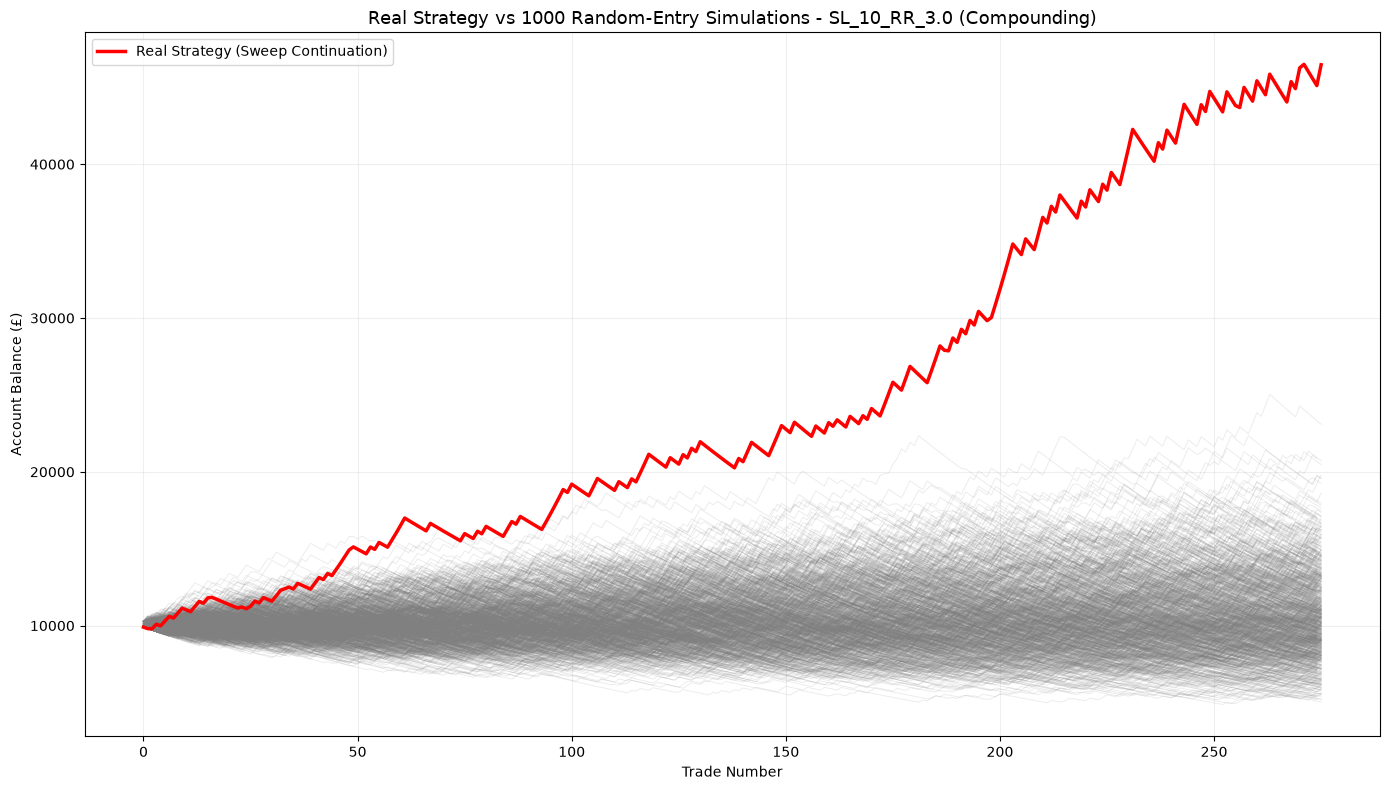

In [16]:
# CELL 14: Plot Equity Curves - Real Strategy vs 1000 Random-Entry Simulations (Compounding)

plt.figure(figsize=(14, 8))

for curve in mc_equity_curves:
    plt.plot(range(len(curve)), curve, color='grey', alpha=0.15, linewidth=0.7)

plt.plot(range(len(real_trades)), real_trades['balance_after'].values,
          color='red', linewidth=2.5, label='Real Strategy (Sweep Continuation)', zorder=1000)

plt.title(f'Real Strategy vs {N_ITERATIONS} Random-Entry Simulations - SL_{SL_DISTANCE}_RR_{RR_RATIO} (Compounding)', fontsize=13)
plt.xlabel('Trade Number')
plt.ylabel('Account Balance (£)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Sanity check - Final balance (original order): £46,468.75
Should match Cell 10 output:                    £46,468.75

TRADE-ORDER PERMUTATION TEST (1000 shuffles, COMPOUNDING, £-based)

Total Return (£) - fixed regardless of order:
  Real value:                       £ 36,468.75

Max Drawdown (£):
  Real value:                       £ -2,071.47
  Shuffled mean:                    £ -3,338.12
  Shuffled std:                     £  1,278.01
  Shuffled min/max:                 £ -9,899.29 / £ -1,316.80
  % of shuffles with DEEPER DD:           89.5%

Return / Max DD Ratio:
  Real value:                          17.6052
  Shuffled mean:                       12.3006
  Shuffled std:                         4.0415
  Shuffled min/max:                     3.6840 /    27.6949
  Real result percentile:                 89.5%


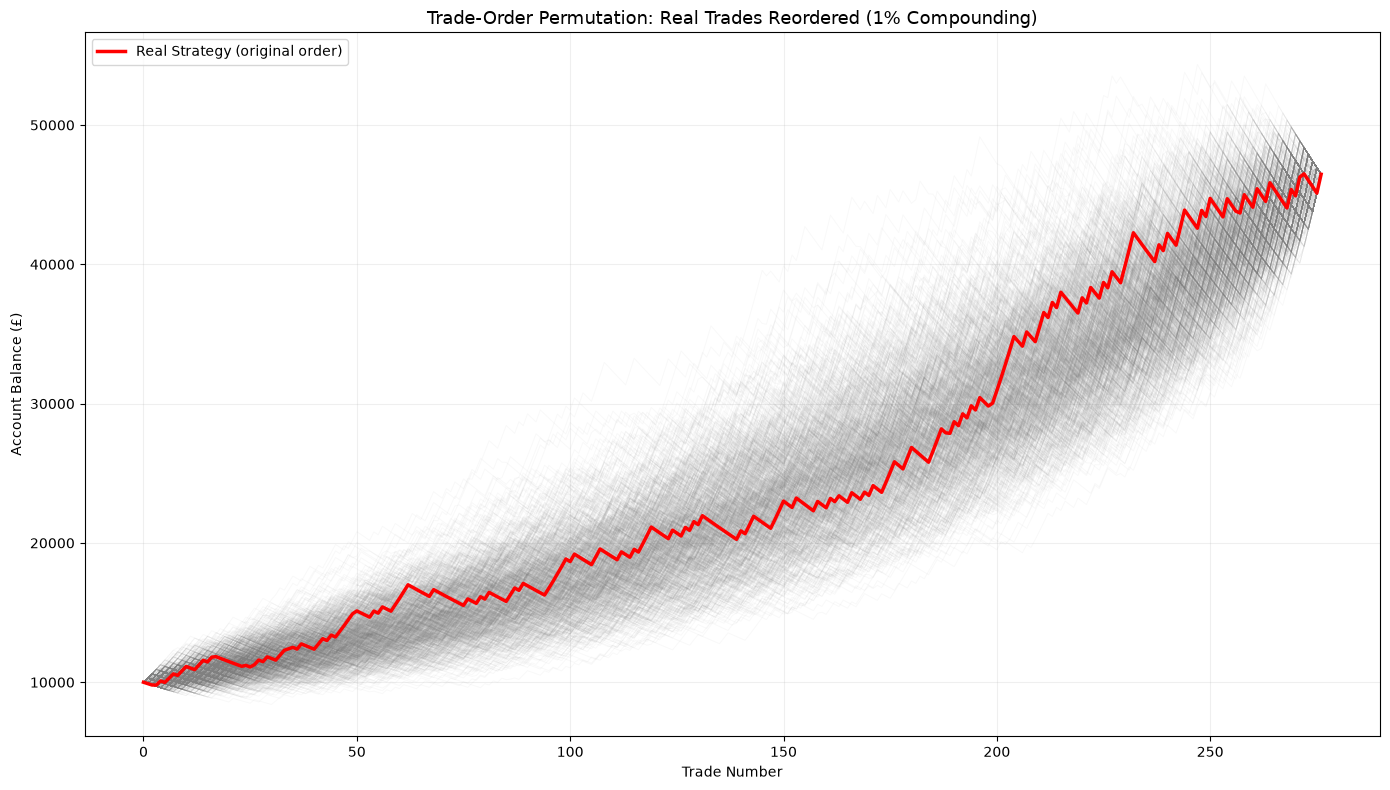

In [17]:
#  CELL 15: Trade-Order Permutation - Plot + Max DD & Return/DD Stats (£-based, matches Cell 10)
# Takes the real strategy's 276 trades (actual realized outcomes), reorders them 1000 times,
# replays each reordering through 1% compounding, and reports Max Drawdown (£) and Return/DD

N_SHUFFLES = 1000

# Get the real strategy's trades and derive each trade's REAL realized R-multiple
real_trades_clean = run_liquidity_setup1_continuation(nas_1m, nas_1d, SL_DISTANCE, RR_RATIO)
real_trades_clean['balance_before'] = real_trades_clean['balance_after'] - real_trades_clean['pnl']
real_trades_clean['risked_amount'] = real_trades_clean['balance_before'] * 0.01
real_trades_clean['r_multiple'] = real_trades_clean['pnl'] / real_trades_clean['risked_amount']

outcomes = real_trades_clean['r_multiple'].values
real_final_balance_expected = real_trades_clean['balance_after'].iloc[-1]

def replay_compounding(outcome_sequence, starting_capital=10000, risk_pct=0.01):
    balance = starting_capital
    balances = [balance]
    for r in outcome_sequence:
        risk_amount = balance * risk_pct
        balance += risk_amount * r
        balances.append(balance)
    return np.array(balances)

def compute_dd_metrics(balances):
    """£-based drawdown and Return/DD, matching Cell 10's convention exactly."""
    running_max = np.maximum.accumulate(balances)
    drawdown_gbp = balances - running_max          # £ drawdown
    max_dd_gbp = drawdown_gbp.min()

    total_return_gbp = balances[-1] - balances[0]   # £ return
    return_dd_ratio = abs(total_return_gbp / max_dd_gbp) if max_dd_gbp != 0 else 0

    return max_dd_gbp, return_dd_ratio, total_return_gbp

# Real (original order) result
real_balances = replay_compounding(outcomes)
real_max_dd, real_return_dd, real_total_return = compute_dd_metrics(real_balances)

print(f"Sanity check - Final balance (original order): £{real_balances[-1]:,.2f}")
print(f"Should match Cell 10 output:                    £{real_final_balance_expected:,.2f}\n")

# Generate all 1000 shuffles ONCE, store both curves and stats together
rng = np.random.default_rng(seed=42)
shuffled_curves = []
shuffled_max_dds = []
shuffled_return_dds = []

for _ in range(N_SHUFFLES):
    shuffled_outcomes = outcomes.copy()
    rng.shuffle(shuffled_outcomes)
    curve = replay_compounding(shuffled_outcomes)
    dd, r_dd, _ = compute_dd_metrics(curve)

    shuffled_curves.append(curve)
    shuffled_max_dds.append(dd)
    shuffled_return_dds.append(r_dd)

shuffled_max_dds = np.array(shuffled_max_dds)
shuffled_return_dds = np.array(shuffled_return_dds)

pct_worse_dd = (shuffled_max_dds < real_max_dd).mean() * 100   # % of shuffles with a DEEPER (more negative) £ drawdown
pct_return_dd = (shuffled_return_dds < real_return_dd).mean() * 100  # % of shuffles with a LOWER Return/DD

print(f"{'='*60}")
print(f"TRADE-ORDER PERMUTATION TEST ({N_SHUFFLES} shuffles, COMPOUNDING, £-based)")
print(f"{'='*60}")
print(f"\nTotal Return (£) - fixed regardless of order:")
print(f"  Real value:                       £{real_total_return:>10,.2f}")

print(f"\nMax Drawdown (£):")
print(f"  Real value:                       £{real_max_dd:>10,.2f}")
print(f"  Shuffled mean:                    £{shuffled_max_dds.mean():>10,.2f}")
print(f"  Shuffled std:                     £{shuffled_max_dds.std():>10,.2f}")
print(f"  Shuffled min/max:                 £{shuffled_max_dds.min():>10,.2f} / £{shuffled_max_dds.max():>10,.2f}")
print(f"  % of shuffles with DEEPER DD:     {pct_worse_dd:>10.1f}%")

print(f"\nReturn / Max DD Ratio:")
print(f"  Real value:                       {real_return_dd:>10.4f}")
print(f"  Shuffled mean:                    {shuffled_return_dds.mean():>10.4f}")
print(f"  Shuffled std:                     {shuffled_return_dds.std():>10.4f}")
print(f"  Shuffled min/max:                 {shuffled_return_dds.min():>10.4f} / {shuffled_return_dds.max():>10.4f}")
print(f"  Real result percentile:           {pct_return_dd:>10.1f}%")
print(f"{'='*60}")


# ── PLOT ──
plt.figure(figsize=(14, 8))

for curve in shuffled_curves:
    plt.plot(range(len(curve)), curve, color='grey', alpha=0.05, linewidth=0.7)

plt.plot(range(len(real_balances)), real_balances,
          color='red', linewidth=2.5, label='Real Strategy (original order)', zorder=1000)

plt.title('Trade-Order Permutation: Real Trades Reordered (1% Compounding)', fontsize=13)
plt.xlabel('Trade Number')
plt.ylabel('Account Balance (£)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 16: Setup 1 CONTINUATION - OUT-OF-SAMPLE (2016-2020), SL_10_RR_3.0, Compounding
# Identical strategy to Cell 10: Long at prev day HIGH, Short at prev day LOW, compounding.
# Same metrics, same output format - only the dataset and config (SL=10, RR=3.0) are fixed.

OOS_START = '2016-01-01'
OOS_END   = '2020-01-01'

nas_1m_oos = trim(load_csv('1m_data.csv'), OOS_START, OOS_END)
nas_1d_oos = trim(load_csv('1d_data.csv'), OOS_START, OOS_END)

print(f"Out-of-sample window: {OOS_START} → {OOS_END}")
print(f"  1m : {len(nas_1m_oos):>8,} rows | {nas_1m_oos.index[0]} → {nas_1m_oos.index[-1]}")
print(f"  1d : {len(nas_1d_oos):>8,} rows | {nas_1d_oos.index[0]} → {nas_1d_oos.index[-1]}")


# ─── RUN SETUP 1 CONTINUATION - SL=10, RR=3.0 (OUT-OF-SAMPLE) ───

oos_trades = run_liquidity_setup1_continuation(nas_1m_oos, nas_1d_oos, SL_DISTANCE, RR_RATIO)

total_return_oos = oos_trades['pnl'].sum()
oos_trades['cumulative_pnl'] = oos_trades['pnl'].cumsum()
oos_trades['running_max'] = oos_trades['cumulative_pnl'].cummax()
max_dd_oos = (oos_trades['cumulative_pnl'] - oos_trades['running_max']).min()
return_dd_ratio_oos = abs(total_return_oos / max_dd_oos) if max_dd_oos != 0 else 0
win_rate_oos = oos_trades['win'].mean() * 100

print(f"\n{'='*60}")
print(f"LIQUIDITY SETUP 1 CONTINUATION (OUT-OF-SAMPLE) - SL_{SL_DISTANCE}_RR_{RR_RATIO}")
print(f"{'='*60}")
print(f"Total trades:           {len(oos_trades):>6}")
print(f"Winning trades:         {oos_trades['win'].sum():>6}")
print(f"Win rate:               {win_rate_oos:>6.2f}%")
print(f"\nTotal Return (P&L):     {total_return_oos:>10.2f}")
print(f"Avg P&L per trade:      {oos_trades['pnl'].mean():>10.4f}")
print(f"Max Drawdown:           {max_dd_oos:>10.2f}")
print(f"Return / Max DD ratio:  {return_dd_ratio_oos:>10.2f}x")
print(f"Final balance:          £{oos_trades['balance_after'].iloc[-1]:>10,.2f}")

final_capital_oos = oos_trades['balance_after'].iloc[-1]
return_pct_oos = ((final_capital_oos - 10000) / 10000) * 100

print(f"\n{'='*60}")
print("PERCENTAGE RETURN ON £10,000 CAPITAL (OUT-OF-SAMPLE, COMPOUNDING)")
print(f"{'='*60}")
print(f"SL_{SL_DISTANCE}_RR_{RR_RATIO}: £10,000 → £{final_capital_oos:,.0f} | Return: {return_pct_oos:.2f}%")
print(f"{'='*60}")

Out-of-sample window: 2016-01-01 → 2020-01-01
  1m : 1,061,102 rows | 2016-11-15 06:33:00-05:00 → 2019-12-31 23:59:00-05:00
  1d :      803 rows | 2016-11-15 00:00:00-05:00 → 2019-12-31 00:00:00-05:00

LIQUIDITY SETUP 1 CONTINUATION (OUT-OF-SAMPLE) - SL_10_RR_3.0
Total trades:              168
Winning trades:             74
Win rate:                44.05%

Total Return (P&L):        3364.50
Avg P&L per trade:         20.0268
Max Drawdown:             -1171.96
Return / Max DD ratio:        2.87x
Final balance:          £ 13,364.50

PERCENTAGE RETURN ON £10,000 CAPITAL (OUT-OF-SAMPLE, COMPOUNDING)
SL_10_RR_3.0: £10,000 → £13,365 | Return: 33.65%


In [ ]:
# CELL 17: Inspect Raw Out-of-Sample Trades
# Print every trade's full detail to see exactly what the strategy did,
# trade by trade, to sanity check the £33.65% / £13,365 result.

pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 150)

oos_trades_display = oos_trades[['date', 'direction', 'entry_price', 'exit_price',
                                   'exit_reason', 'pnl', 'win', 'balance_after']].copy()
oos_trades_display['pnl'] = oos_trades_display['pnl'].round(2)
oos_trades_display['balance_after'] = oos_trades_display['balance_after'].round(2)

print(f"Total trades: {len(oos_trades_display)}")
print(f"\n{oos_trades_display.to_string(index=True)}")

# Quick breakdown of exit reasons - this often reveals the real story
print(f"\n{'='*60}")
print("EXIT REASON BREAKDOWN")
print(f"{'='*60}")
print(oos_trades['exit_reason'].value_counts())
print(f"\nWin rate by exit reason:")
print(oos_trades.groupby('exit_reason')['win'].agg(['mean', 'count']))

Total trades: 168

           date direction  entry_price  exit_price   exit_reason     pnl  win  balance_after
0    2016-11-28     short       4854.5      4864.5        sl_hit -100.00    0        9900.00
1    2016-12-02     short       4724.8      4734.8        sl_hit  -99.00    0        9801.00
2    2016-12-05      long       4760.8      4759.6  market_close  -11.76    0        9789.24
3    2016-12-09      long       4873.7      4882.8  market_close   89.08    1        9878.32
4    2017-01-13      long       5049.5      5048.5  market_close   -9.88    0        9868.44
5    2017-01-17     short       5049.5      5050.0  market_close   -4.93    0        9863.51
6    2017-01-24      long       5068.1      5069.8  market_close   16.77    1        9880.28
7    2017-01-30     short       5147.1      5152.2  market_close  -50.39    0        9829.89
8    2017-02-07      long       5168.8      5174.8  market_close   58.98    1        9888.87
9    2017-02-09      long       5202.0      5197.4 

Sanity check - Final balance (original order): £13,364.50
Should match Cell 16 output:                    £13,364.50

TRADE-ORDER PERMUTATION TEST - OUT-OF-SAMPLE 2016-2019 (1000 shuffles)

Final Balance (£) - varies with order this time, since this checks
how much the LOW result was a product of unlucky sequencing:
  Real value:                       £ 13,364.50
  Shuffled mean:                    £ 13,364.50
  Shuffled std:                     £      0.00
  Shuffled min/max:                 £ 13,364.50 / £ 13,364.50
  Real result percentile:                  8.1%

Max Drawdown (£):
  Real value:                       £ -1,171.96
  Shuffled mean:                    £ -1,184.09
  Shuffled std:                     £    352.90
  Shuffled min/max:                 £ -2,976.15 / £   -629.37
  % of shuffles with DEEPER DD:           42.8%

Return / Max DD Ratio:
  Real value:                           2.8708
  Shuffled mean:                        3.0719
  Shuffled std:                      

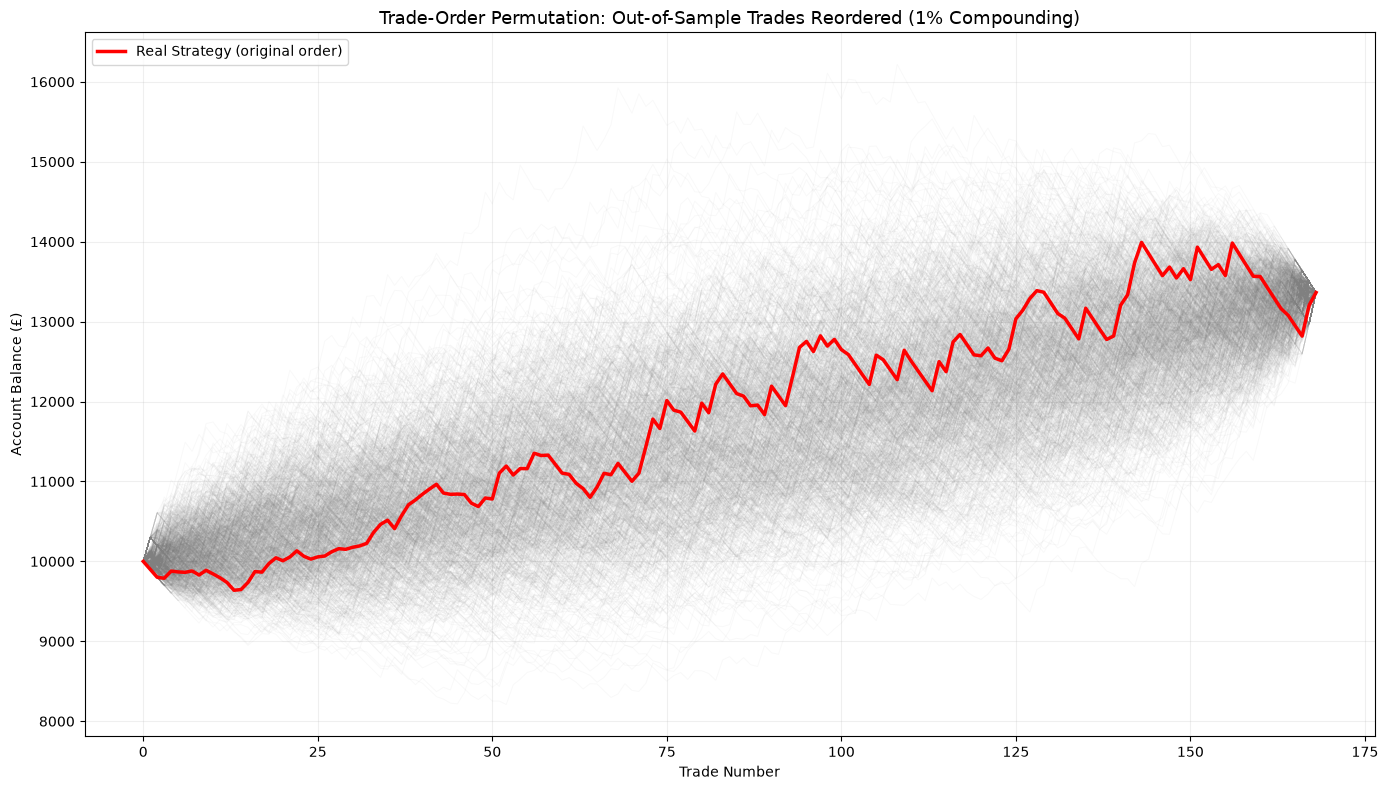

In [ ]:
# ── CELL 18: Trade-Order Permutation - Out-of-Sample (2016-2019) Trades, Compounding
# Takes the 168 real out-of-sample trades (actual realized outcomes), reorders them 1000 times,
# replays each reordering through 1% compounding, and reports Max Drawdown (£) and Return/DD
# apparent underperformance (vs fixed-risk sizing) was a typical or unusually unlucky sequence.

N_SHUFFLES = 1000

# Get the out-of-sample trades and derive each trade's REAL realized R-multiple
oos_trades_clean = run_liquidity_setup1_continuation(nas_1m_oos, nas_1d_oos, SL_DISTANCE, RR_RATIO)
oos_trades_clean['balance_before'] = oos_trades_clean['balance_after'] - oos_trades_clean['pnl']
oos_trades_clean['risked_amount'] = oos_trades_clean['balance_before'] * 0.01
oos_trades_clean['r_multiple'] = oos_trades_clean['pnl'] / oos_trades_clean['risked_amount']

outcomes_oos = oos_trades_clean['r_multiple'].values
oos_final_balance_expected = oos_trades_clean['balance_after'].iloc[-1]

def replay_compounding(outcome_sequence, starting_capital=10000, risk_pct=0.01):
    balance = starting_capital
    balances = [balance]
    for r in outcome_sequence:
        risk_amount = balance * risk_pct
        balance += risk_amount * r
        balances.append(balance)
    return np.array(balances)

def compute_dd_metrics(balances):
    """£-based drawdown and Return/DD, matching Cell 10/15/16's convention."""
    running_max = np.maximum.accumulate(balances)
    drawdown_gbp = balances - running_max
    max_dd_gbp = drawdown_gbp.min()

    total_return_gbp = balances[-1] - balances[0]
    return_dd_ratio = abs(total_return_gbp / max_dd_gbp) if max_dd_gbp != 0 else 0

    return max_dd_gbp, return_dd_ratio, total_return_gbp

# Real (original order) out-of-sample result
oos_balances = replay_compounding(outcomes_oos)
oos_max_dd, oos_return_dd, oos_total_return = compute_dd_metrics(oos_balances)

print(f"Sanity check - Final balance (original order): £{oos_balances[-1]:,.2f}")
print(f"Should match Cell 16 output:                    £{oos_final_balance_expected:,.2f}\n")

# Generate all 1000 shuffles ONCE, store both curves and stats together
rng = np.random.default_rng(seed=42)
shuffled_curves_oos = []
shuffled_max_dds_oos = []
shuffled_return_dds_oos = []
shuffled_final_balances_oos = []

for _ in range(N_SHUFFLES):
    shuffled_outcomes = outcomes_oos.copy()
    rng.shuffle(shuffled_outcomes)
    curve = replay_compounding(shuffled_outcomes)
    dd, r_dd, _ = compute_dd_metrics(curve)

    shuffled_curves_oos.append(curve)
    shuffled_max_dds_oos.append(dd)
    shuffled_return_dds_oos.append(r_dd)
    shuffled_final_balances_oos.append(curve[-1])

shuffled_max_dds_oos = np.array(shuffled_max_dds_oos)
shuffled_return_dds_oos = np.array(shuffled_return_dds_oos)
shuffled_final_balances_oos = np.array(shuffled_final_balances_oos)

pct_worse_dd = (shuffled_max_dds_oos < oos_max_dd).mean() * 100
pct_return_dd = (shuffled_return_dds_oos < oos_return_dd).mean() * 100
pct_final_balance = (shuffled_final_balances_oos < oos_balances[-1]).mean() * 100

print(f"{'='*60}")
print(f"TRADE-ORDER PERMUTATION TEST - OUT-OF-SAMPLE 2016-2019 ({N_SHUFFLES} shuffles)")
print(f"{'='*60}")
print(f"\nFinal Balance (£) - varies with order this time, since this checks")
print(f"how much the LOW result was a product of unlucky sequencing:")
print(f"  Real value:                       £{oos_balances[-1]:>10,.2f}")
print(f"  Shuffled mean:                    £{shuffled_final_balances_oos.mean():>10,.2f}")
print(f"  Shuffled std:                     £{shuffled_final_balances_oos.std():>10,.2f}")
print(f"  Shuffled min/max:                 £{shuffled_final_balances_oos.min():>10,.2f} / £{shuffled_final_balances_oos.max():>10,.2f}")
print(f"  Real result percentile:           {pct_final_balance:>10.1f}%")

print(f"\nMax Drawdown (£):")
print(f"  Real value:                       £{oos_max_dd:>10,.2f}")
print(f"  Shuffled mean:                    £{shuffled_max_dds_oos.mean():>10,.2f}")
print(f"  Shuffled std:                     £{shuffled_max_dds_oos.std():>10,.2f}")
print(f"  Shuffled min/max:                 £{shuffled_max_dds_oos.min():>10,.2f} / £{shuffled_max_dds_oos.max():>10,.2f}")
print(f"  % of shuffles with DEEPER DD:     {pct_worse_dd:>10.1f}%")

print(f"\nReturn / Max DD Ratio:")
print(f"  Real value:                       {oos_return_dd:>10.4f}")
print(f"  Shuffled mean:                    {shuffled_return_dds_oos.mean():>10.4f}")
print(f"  Shuffled std:                     {shuffled_return_dds_oos.std():>10.4f}")
print(f"  Shuffled min/max:                 {shuffled_return_dds_oos.min():>10.4f} / {shuffled_return_dds_oos.max():>10.4f}")
print(f"  Real result percentile:           {pct_return_dd:>10.1f}%")
print(f"{'='*60}")


# ── PLOT ──
plt.figure(figsize=(14, 8))

for curve in shuffled_curves_oos:
    plt.plot(range(len(curve)), curve, color='grey', alpha=0.05, linewidth=0.7)

plt.plot(range(len(oos_balances)), oos_balances,
          color='red', linewidth=2.5, label='Real Strategy (original order)', zorder=1000)

plt.title('Trade-Order Permutation: Out-of-Sample Trades Reordered (1% Compounding)', fontsize=13)
plt.xlabel('Trade Number')
plt.ylabel('Account Balance (£)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 19: Out-of-Sample Test - SL=5, RR=3.0 (Compounding)
# Tests whether a tighter 5-point stop loss reduces the market_close exit rate

oos_trades_sl5 = run_liquidity_setup1_continuation(nas_1m_oos, nas_1d_oos, 5, 3.0)

total_return_sl5 = oos_trades_sl5['pnl'].sum()
oos_trades_sl5['cumulative_pnl'] = oos_trades_sl5['pnl'].cumsum()
oos_trades_sl5['running_max'] = oos_trades_sl5['cumulative_pnl'].cummax()
max_dd_sl5 = (oos_trades_sl5['cumulative_pnl'] - oos_trades_sl5['running_max']).min()
return_dd_ratio_sl5 = abs(total_return_sl5 / max_dd_sl5) if max_dd_sl5 != 0 else 0
win_rate_sl5 = oos_trades_sl5['win'].mean() * 100
final_balance_sl5 = oos_trades_sl5['balance_after'].iloc[-1]
return_pct_sl5 = ((final_balance_sl5 - 10000) / 10000) * 100

print(f"{'='*60}")
print(f"LIQUIDITY SETUP 1 CONTINUATION (OUT-OF-SAMPLE) - SL_5_RR_3.0")
print(f"{'='*60}")
print(f"Total trades:           {len(oos_trades_sl5):>6}")
print(f"Winning trades:         {oos_trades_sl5['win'].sum():>6}")
print(f"Win rate:               {win_rate_sl5:>6.2f}%")
print(f"\nTotal Return (P&L):     {total_return_sl5:>10.2f}")
print(f"Max Drawdown:           {max_dd_sl5:>10.2f}")
print(f"Return / Max DD ratio:  {return_dd_ratio_sl5:>10.2f}x")
print(f"Final balance:          £{final_balance_sl5:>10,.2f}")
print(f"Return:                 {return_pct_sl5:>10.2f}%")

print(f"\n{'='*60}")
print("EXIT REASON BREAKDOWN (SL=5)")
print(f"{'='*60}")
print(oos_trades_sl5['exit_reason'].value_counts())
print(f"\nWin rate by exit reason:")
print(oos_trades_sl5.groupby('exit_reason')['win'].agg(['mean', 'count']))

LIQUIDITY SETUP 1 CONTINUATION (OUT-OF-SAMPLE) - SL_5_RR_3.0
Total trades:              168
Winning trades:             80
Win rate:                47.62%

Total Return (P&L):       17548.50
Max Drawdown:             -2575.39
Return / Max DD ratio:        6.81x
Final balance:          £ 27,548.50
Return:                     175.48%

EXIT REASON BREAKDOWN (SL=5)
exit_reason
sl_hit          75
tp_hit          49
market_close    44
Name: count, dtype: int64

Win rate by exit reason:
                  mean  count
exit_reason                  
market_close  0.704545     44
sl_hit        0.000000     75
tp_hit        1.000000     49
